In [1]:
import netCDF4 as nc
import numpy as np
from scipy.sparse import csr_matrix

# The usual
from datetime import date
import xarray as xr
import matplotlib.pyplot as plt
import importlib
#import make_event_cubes as mec


wgtfile='../mpasa3p75_TO_UHR_SO-Global_bilin.nc'

In [2]:
foo='/glade/derecho/scratch/juliob/archive/GW_event_analysis/ds/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_0d2260-1e06.nc'
foo='/glade/derecho/scratch/juliob/archive/GW_event_analysis/ds/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_0d3428-1e06.nc'
ds=xr.open_dataset( foo )

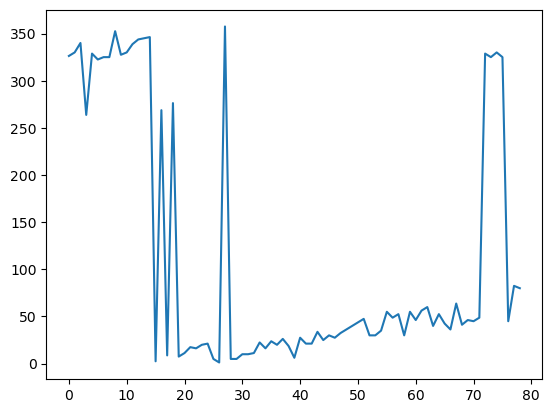

In [3]:
plt.plot( ds.lon_event.values )

In [4]:
import make_event_cubes as mec #import make_regridder, extract_event_cube
importlib.reload(mec)
# Do this once at the top of your notebook/script
W, nlat, nlon, lat1d_hr, lon1d_hr = mec.make_regridder(wgtfile)

Regridder ready: 1350 lat x 10412 lon
  lat: -65.000 to -35.000 deg
  lon: 0.000 to 359.965 deg


In [5]:
# Then call this for each event
cube = mec.extract_event_cube(62, ds, W, nlat, nlon, lat1d_hr, lon1d_hr)

Event 62  (id=78)  t=2016-08-24-64800  lat=-41.94  lon=60.00
  File A: /glade/derecho/scratch/juliob/archive/cam77_dyamond1_prod1/atm/hist/DynVars_dyamond_fv1x1.2016-08-24-64800.nc
  File B: /glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/2016-08-24-64800/w_mpas_prt_dyamond.2016-08-24-64800.nc
  Upwp: (59, 192, 288) → patch (59, 11, 9)
  Vpwp: (59, 192, 288) → patch (59, 11, 9)
  rho_mpas: (58, 192, 288) → patch (58, 11, 9)
  w_mpas_prt: raw shape (1, 59, 41943042) → squeezed (59, 41943042)
  w_mpas_prt: averaged to midpoints → (58, 41943042)
  w_mpas_yx: (58, 449, 289)


In [6]:
cube.keys()

dict_keys(['event_idx', 'event_id', 'itime', 'time_event', 'lat_event', 'lon_event', 'lat_A', 'lon_A', 'lat_hr', 'lon_hr', 'zlev', 'Upwp', 'Vpwp', 'rho_mpas', 'w_mpas_yx'])

In [7]:
epwp = np.sqrt(cube['Upwp']**2+cube['Vpwp']**2)

11526.291
-41.98295033358043


"\np=0\nax=axs[p]\n#plt.contour( epwp[23,:,:] )\nw_co_ = ax.contourf( cube['lon_hr'], cube['lat_hr'], cube['w_mpas_yx'][z,:,:], levels=wlevs, cmap='bwr' )\nax.contour( cube['lon_A'], cube['lat_A'], epwp[z,:,:] )\nplt.colorbar( w_co_ )\np=p+1\nax=axs[p]\n#plt.contour( epwp[23,:,:] )\nw_co_ = ax.contourf( cube['lon_hr'], cube['zlev'], cube['w_mpas_yx'][:,y,:], levels=wlevs, cmap='bwr'  )\nax.contour( cube['lon_A'], cube['zlev'], epwp[1:,5,:] )\nax.set_ylim(0,15_000)\nplt.colorbar( w_co_ )\n"

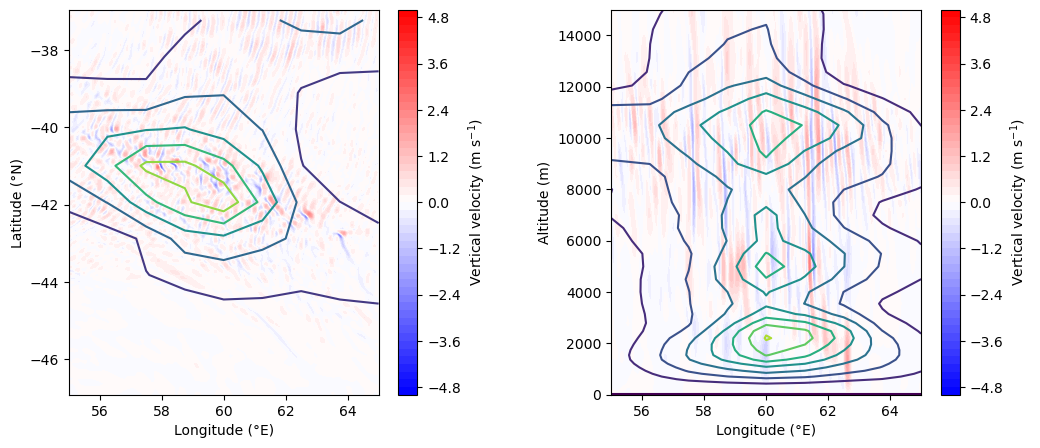

In [35]:
z=20
y=222
print(cube['zlev'][z])
print(cube['lat_hr'][y])
wlevs=np.linspace(-5,5,num=51)


#fig,axs=plt.subplots( 1,2, figsize=(12,5) )

fig, axs = plt.subplots(1, 2, figsize=(12,5) ,gridspec_kw={'wspace': 0.4})

p=0
ax=axs[p]
w_co_ = ax.contourf( cube['lon_hr'], cube['lat_hr'], cube['w_mpas_yx'][z,:,:], levels=wlevs, cmap='bwr' )
ax.contour( cube['lon_A'], cube['lat_A'], epwp[z,:,:] )
cb = plt.colorbar( w_co_, ax=ax )
cb.set_label('Vertical velocity (m s$^{-1}$)', fontsize=10)
ax.set_xlabel('Longitude (°E)', fontsize=10)
ax.set_ylabel('Latitude (°N)', fontsize=10)
p=p+1

ax=axs[p]
w_co_ = ax.contourf( cube['lon_hr'], cube['zlev'], cube['w_mpas_yx'][:,y,:], levels=wlevs, cmap='bwr' )
ax.contour( cube['lon_A'], cube['zlev'], epwp[1:,5,:] )
ax.set_ylim(0,15_000)
cb = plt.colorbar( w_co_, ax=ax )
cb.set_label('Vertical velocity (m s$^{-1}$)', fontsize=10)
ax.set_ylabel('Altitude (m)', fontsize=10)
ax.set_xlabel('Longitude (°E)', fontsize=10)

"""
p=0
ax=axs[p]
#plt.contour( epwp[23,:,:] )
w_co_ = ax.contourf( cube['lon_hr'], cube['lat_hr'], cube['w_mpas_yx'][z,:,:], levels=wlevs, cmap='bwr' )
ax.contour( cube['lon_A'], cube['lat_A'], epwp[z,:,:] )
plt.colorbar( w_co_ )
p=p+1
ax=axs[p]
#plt.contour( epwp[23,:,:] )
w_co_ = ax.contourf( cube['lon_hr'], cube['zlev'], cube['w_mpas_yx'][:,y,:], levels=wlevs, cmap='bwr'  )
ax.contour( cube['lon_A'], cube['zlev'], epwp[1:,5,:] )
ax.set_ylim(0,15_000)
plt.colorbar( w_co_ )
"""


In [10]:
print(nlon,nlat)

10412 1350


In [9]:

ftopo='/glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/TimeInvariant/PHIS_dyamond.nc'
Topo=xr.open_dataset( ftopo )
print( Topo['PHIS'].dims)
print( Topo['PHIS'].shape)
print( Topo.dims)


phis=Topo.PHIS.values

('ncol',)
(41943042,)
FrozenMappingWarningOnValuesAccess({'ncol': 41943042})


In [11]:
def regrid(field_mpas, W, nlat, nlon):
    """
    field_mpas : np.ndarray, shape (n_src,) or (nz, n_src) or (nt, nz, n_src)
    Returns shape (..., nlat, nlon)
    """
    orig_shape = field_mpas.shape[:-1]
    flat = field_mpas.reshape(-1, field_mpas.shape[-1])  # (nfields, n_src)
    out  = (W @ flat.T).T                                 # (nfields, nlat*nlon)
    return out.reshape(orig_shape + (nlat, nlon))

In [15]:
phis_yx=regrid(phis, W, nlat, nlon)
lat_yx=regrid(Topo.lat.values , W, nlat, nlon)
lon_yx=regrid(Topo.lon.values , W, nlat, nlon)


Text(0, 0.5, 'Latitude (°N)')

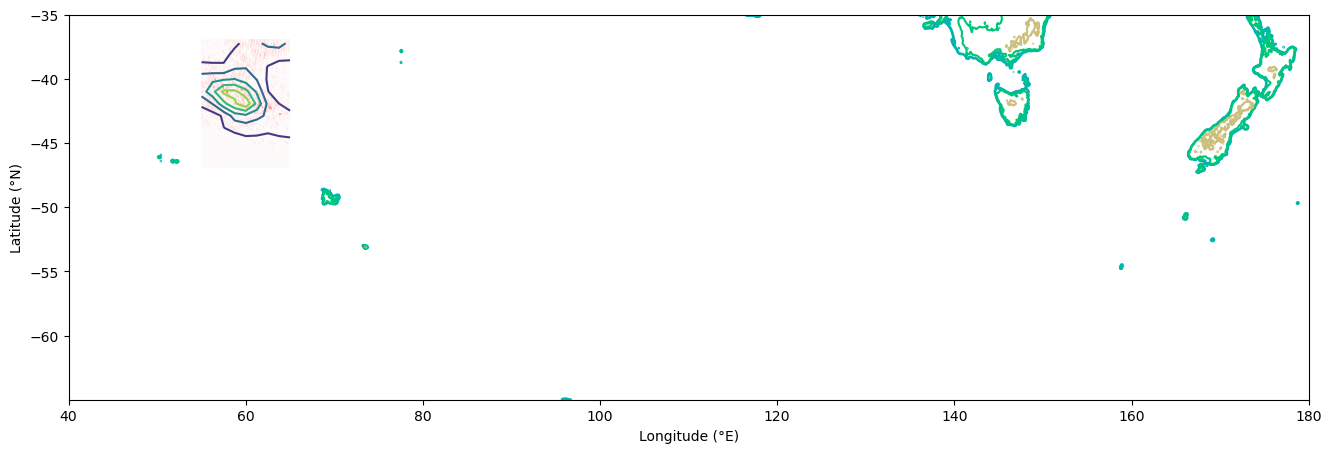

In [34]:
fig,ax=plt.subplots( 1,1, figsize=(16,5) )
ax.contour( lon_yx, lat_yx, phis_yx/9.8 ,levels=[-500,1,10,100,1000,2000],cmap='terrain')
w_co_ = ax.contourf( cube['lon_hr'], cube['lat_hr'], cube['w_mpas_yx'][z,:,:], levels=wlevs, cmap='bwr' )
ax.contour( cube['lon_A'], cube['lat_A'], epwp[z,:,:] )
ax.set_xlim(40,180)
ax.set_xlabel('Longitude (°E)', fontsize=10)
ax.set_ylabel('Latitude (°N)', fontsize=10)


In [ ]:
cube['w_mpas_yx'].shape

In [ ]:
y=222
print(cube['lat_hr'][y])


#plt.contour( epwp[23,:,:] )
plt.contourf( cube['lon_hr'], cube['zlev'], cube['w_mpas_yx'][:,y,:], levels=wlevs, cmap='bwr'  )
plt.ylim(0,20_000)
#plt.contour( cube['lon_A'], cube['lat_A'], epwp[z,:,:] )


In [ ]:
fB='/glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/2016-08-24-10800/w_mpas_prt_dyamond.2016-08-24-10800.nc'
var_B='w_mpas_prt'
dsB = xr.open_dataset(fB)
print(dsB[var_B].dims)
print(dsB[var_B].shape)
print(dsB.dims)

ftopo='/glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/TimeInvariant/PHIS_dyamond.nc'
Topo=xr.open_dataset( ftopo )
print( Topo['PHIS'].dims)
print( Topo['PHIS'].shape)
print( Topo.dims)


phis=Topo.PHIS.values

In [ ]:
with nc.Dataset(wgtfile) as f:
    print(f.variables.keys())
    row = f.variables['row'][:]-1
    col = f.variables['col'][:]-1
    S   = f.variables['S'][:]
    print(f"row range: {row.min()} – {row.max()}")
    print(f"col range: {col.min()} – {col.max()}")
    print(f"n_weights: {len(S)}")
    dst_dims = f.variables['dst_grid_dims'][:]
    src_dims = f.variables['src_grid_dims'][:]
    print(f"dst_grid_dims: {dst_dims}")  # expect [nlon, nlat] — note ESMF is lon-first!
    print(f"src_grid_dims: {src_dims}")
    yc_b     = f.variables['yc_b'][:]           # destination latitudes, shape (n_dst,)
    xc_b     = f.variables['xc_b'][:]           # destination longitudes, shape (n_dst,)
    yc_a     = f.variables['yc_a'][:]           # Source latitudes, shape (n_src,)
    xc_a     = f.variables['xc_a'][:]           # Source longitudes, shape (n_src,)

n_src=src_dims[0]
nlon,nlat = dst_dims

# build sparse weight matrix — do this once
W = csr_matrix((S, (row, col)), shape=(nlat*nlon, n_src))

# reconstruct 2D lat/lon grids for the destination
lat2d = yc_b.reshape(nlat, nlon)
lon2d = xc_b.reshape(nlat, nlon)

# extract 1D axes (should be regular — check)
lat1d = lat2d[:, 0]
lon1d = lon2d[0, :]
print(f"lat: {lat1d[0]:.4f} to {lat1d[-1]:.4f},  dlat={np.diff(lat1d).mean():.5f}")
print(f"lon: {lon1d[0]:.4f} to {lon1d[-1]:.4f},  dlon={np.diff(lon1d).mean():.5f}")


ftopo='/glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/TimeInvariant/PHIS_dyamond.nc'
Topo=xr.open_dataset( ftopo )

phis=Topo.PHIS.values

In [ ]:
phis_yx = regrid( phis, W, nlat, nlon )

In [ ]:
plt.plot(lon1d)

In [ ]:
print(np.max( xc_a) )

In [ ]:
# mask to your region
yc_a_deg = np.degrees(yc_a)
xc_a_deg = np.degrees(xc_a)

mask = (yc_a_deg >= -65) & (yc_a_deg <= -35) & (xc_a_deg >= 0) & (xc_a_deg <= 360)
print(f"mask sum: {mask.sum()}")

fig,axs=plt.subplots(2,1, figsize=(20,10) )
ax=axs[0]
ax.tricontourf(xc_a_deg[mask], yc_a_deg[mask], phis[mask]/9.8, levels=[-1,0,1,10,100,1000] )
ax=axs[1]
ax.contourf(lon1d, lat1d, phis_yx/9.8, levels=[-1,0,1,10,100,1000] )


In [ ]:
print( src_dims[0])
nlon,nlat = dst_dims

In [ ]:
import matplotlib.pyplot as plt
plt.plot(xc_b)

In [ ]:
ds

In [ ]:
print( ds.time_event[0].values )
print( ds.itime[0].values )
ds.time_event

In [ ]:
plt.plot( Ds.itime.values ,'o')

In [ ]:
import event_utils as euti
ds_drop=ds.drop_vars( ['lat','lon','zlev'] )


event_list=euti.ds_to_event_list( ds_drop )

In [ ]:
ev=event_list[1]
print(ev)

In [ ]:
for tootoo in ds.time_event:
    print(tootoo.values)


In [ ]:
for ev in event_list:
    if len(ev) > 0:
        
        

In [ ]:
importlib.reload( auti )
auti.plot_xavg_compos( fld='zeta_4D', El=El )
auti.plot_xavg_compos( fld='tilt_4D', El=El )
auti.plot_xavg_compos( fld='fgf_4D', El=El )
